# *RFM-Based Customer Segmentation & Marketing Strategy*  


<br>  

### **A Data Analytics Project**  
![Superstore](https://upload.wikimedia.org/wikipedia/commons/3/3a/Superstore_Logo.png)  

#### **Author:** Amos Vante, Agricultural Economist & Data Analyst  
#### **Date:** July 2025  
#### **Tools Used:** Python, Pandas, Matplotlib, Seaborn  
#### **Dataset:** Superstore (2024) 

---

## Table of Contents
1. [Introduction](#introduction)
2. [Data Preparation](#data-preparation)
3. [RFM Segmentation Methodology](#rfm-segmentation-methodology)
4. [Segment and Revenue Analysis](#segment-and-revenue-analysis)
5. [Conclusions and Actionable Business Recommendations](#conclusions-and-actionable-business-recommendations)
6. [Annex— Segment Descriptive Statistics](#annex-segment-descriptive-statistics)
7. [References](#references)

# Executive Summary

This project applies RFM (Recency, Frequency, Monetary) analysis to segment retail customers based on purchasing behavior and generate actionable insights for retention, growth, and revenue optimization.

## Key Findings

- Revenue is moderately concentrated among top-value segments, with **Champions (19.8%) and Loyal Customers (10.7%) contributing over 30% of total revenue**, confirming their role as primary value drivers.

- The largest segment is **Potential Loyalists (17.8%)**, representing a key opportunity to convert mid-tier customers into long-term high-value buyers.

- Approximately **28% of customers fall into declining or inactive segments** (About to Sleep, Hibernating, Lost), indicating meaningful churn risk and reduced engagement.

- Overall, revenue is driven by a mix of high-value and mid-tier customers, with a relatively broad distribution rather than extreme concentration.

## Strategic Recommendations

A structured four-tier strategy is recommended:

- **Retain high-value customers (Champions, Loyal Customers, At Risk)**  
Focus on loyalty programs, personalized engagement, and proactive retention to maximize customer lifetime value.

- **Grow mid-tier segments (Potential Loyalists, Promising, New Customers)**  
Improve onboarding, personalization, and targeted incentives to increase repeat purchase behavior.

- **Recover at-risk customers (Can't Lose Them, About to Sleep)**  
Deploy targeted win-back campaigns with time-sensitive, high-impact offers.

- **Minimize cost in inactive segments (Hibernating, Lost)**  
Use automated, low-cost reactivation campaigns to test recovery potential efficiently.

## Key Business Risk

The primary risk is gradual erosion of the mid-tier customer base, which serves as the pipeline into high-value segments. Without intervention, this may increase reliance on existing Champions, leading to long-term revenue stagnation and higher acquisition costs.

###

# 1. Introduction<a id="introduction"></a>

Customer retention and customer value optimization are major challenges in retail and e-commerce businesses. Companies need to understand customer purchasing behavior in order to identify their most valuable customers, detect customers at risk of churn, and design targeted marketing strategies.

Customer segmentation helps businesses group customers according to behavioral patterns and purchasing habits. One of the most widely used customer segmentation techniques is the RFM framework, which evaluates customers based on:
- Recency (R): How recently a customer made a purchase
- Frequency (F): How often a customer makes purchases
- Monetary (M): How much revenue a customer generates

By combining these three dimensions, businesses can better understand customer engagement, loyalty, and value.

This project applies RFM analysis to the Superstore dataset in order to segment customers according to their purchasing behavior and generate business-oriented insights.
The analysis aims to:
- Identify high-value and loyal customers
- Detect customers showing signs of disengagement
- Discover low-engagement customer groups
- Analyze customer value distribution
- Support data-driven marketing and retention strategies

The project combines:
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Quantile-based RFM scoring
- Customer segmentation
- Statistical analysis
- Data visualization
- Business insight generation

## 1.1 Business Understanding

In retail environments, customer behavior is highly heterogeneous. A relatively small group of customers often generates a large share of total revenue, while many customers purchase infrequently or become inactive over time.

Without customer segmentation, businesses may apply the same marketing strategy to all customers, which can lead to:
- inefficient marketing spending
- lower customer retention
- missed upselling opportunities
- poor customer personalization

RFM analysis helps solve this problem by grouping customers according to purchasing behavior and customer value.

Different customer segments require different business strategies. For example:
- high-value loyal customers should be retained and rewarded
- at-risk customers may require reactivation campaigns
- new customers may benefit from onboarding promotions
- low-engagement customers may require personalized offers

This makes RFM analysis a valuable tool for Customer Relationship Management (CRM), customer retention, and revenue optimization.

## 1.2 Project Objectives

The main objectives of this project are to:
- Prepare and clean transactional retail data
- Compute Recency, Frequency, and Monetary metrics for each customer
- Analyze the statistical distribution of RFM variables
- Assign RFM scores using quantile-based segmentation
- Create meaningful customer segments
- Visualize customer behavior patterns
- Generate business-oriented recommendations based on customer segments

The next section introduces the dataset and the preprocessing steps required before conducting the RFM analysis.

###

#  2.  Data Preparation <a id="data-preparation"></a>

## 2.1. Data Description
In this project, we utilize the Superstore dataset, a well-known dataset available online in multiple formats. For this analysis, we work with an Excel file containing over 10,000 transactional records from a retail business operating across the United States and Canada. The dataset spans a four-year period from January 2021 to December 2024, offering detailed insights into various aspects of the business through four primary dimensions:
- **Products**: Detailed categorization of items sold, including categories and subcategories.
- **Customers**: Demographics such as regions, states, and customer segments (e.g., Consumer, Corporate).
- **Orders**: Transaction-level details, including sales, profit, quantities, and discounts.
- **Shipping**: Shipping methods and delivery times.

Each record represents a transaction, enabling analysis of sales performance, customer segmentation, and operational efficiency at both granular and macro levels.

For this project, the analysis focuses specifically on customer purchasing behavior within the United States market.

### Key variables used for RFM analysis::
| Column Name       | Description                                       
|-------------------|----------------------------------------------------------------------|
| `Customer ID`     | Unique identifier for each customer                                  |
| `Order ID`        | Transaction identifier used for frequency calculation                 
| `Order Date`      | Date the order was placed (used for recency calculation)             |
| `Sales`           | Revenue generated from the order (used for monetary calculation)     |


## 2.2. Key Libraries and Visualization Settings

In [388]:
# a) Importing key libraries :

import pandas as pd      # For data manipulation and analysis, particularly for handlingdata in DataFrame format.
import numpy as np       # For numerical operations
import matplotlib.pyplot as plt  # For creating static visualizations
import seaborn as sns  # For more advanced visualization (it is built on matplotlib)
#---------------------------------------------------------

# b) Global Settings for the  Visualizations

# - Seaborn Theme Global Style
sns.set_theme(
    style="whitegrid",
    rc={
        "axes.titlesize": 15,      
        "axes.titleweight": "bold",
        "axes.labelsize": 12,      
        "legend.fontsize": 11,    
        "xtick.labelsize": 11,     
        "ytick.labelsize": 11,
        "axes.labelweight": "normal",  
        "axes.titlepad": 10
    })
# Purpose: 
# - Ensures consistent styling across all visualizations
#- Improves readability for business presentations
#- Applies a clean grid-based layout suitable for analytics reporting


 # - Global settings (Matplotlib)
plt.rcParams["figure.figsize"] = (16, 10) 
# Set a default figure size for all plots

plt.rcParams["figure.autolayout"] = True 

# Automatically adjust plot spacing to reduce overlapping or clipped elements such as titles,labels, legends, and tick labels.
# However, in more complex figures (e.g., subplots, heatmaps, long labels, or rotated ticks), additional manual adjustment may still be required using:
# plt.tight_layout()
#---------------------------------------------------------------

# c) RFM Metric color system for non-segmented plots
rfm_colors = {
    'Recency': 'mediumpurple',  
    'Frequency': 'royalblue',    
    'Monetary': 'darkorange'    
}

# Purpose:
# - Assign a fixed visual identity to each RFM dimension
# - Ensure consistency across all distribution and box plots
# - Improve interpretability and comparison across metrics
#------------------------------------------------------------------

# d) Segment color system for segmented plots
segment_palette = {
    'Champions': '#1f77b4',             #  blue
    'Loyal Customers': '#2a9d8f',      # teal
    'Potential Loyalists': '#48bfe3',    
    'New Customers': '#457b9d',         # oblue
    'Promising': '#90be6d',             # green 
    'Active Low-Spenders': '#a8dadc',   
    'Need Attention': '#f8961e',        
    'About to Sleep': '#f3722c',       
    'At Risk': '#e76f51',              # red-orange
    "Can't Lose Them": '#c1121f',      #  
    'Hibernating': '#adb5bd',          # light gray
    'Lost': '#495057'                  # dark gray
}
# Purpose:
# - Create a consistent “business language” for customer segments
# - Ensures identical segment colors across all  segmented charts (bar charts, scatter plots with hue, etc.).

## 2.3. Data Import and Quick Preview

In [389]:
# a) Data Loading (reading the excel data file) 
data=pd.read_excel(r"C:\Users\amosv\OneDrive\Desktop\Customer Segmentation_project\superstore _2024.xlsx")

# b) Quick preview to verify loading success
print(f"Superstore dataset: {data.shape[0]} Rows and {data.shape[1]} Columns\n")
data.head()

Superstore dataset: 10194 Rows and 21 Columns



,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2021-103800,2021-01-03,2021-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2021-112326,2021-01-04,2021-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2021-112326,2021-01-04,2021-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2021-112326,2021-01-04,2021-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2021-141817,2021-01-05,2021-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


## 2.4. Data Filtering 

The dataset includes transaction records from both the United States and Canada. However, to ensure a consistent and comparable analytical framework, we will filter the dataset to focus exclusively on transactions from the United States.

This decision helps reduce potential bias introduced by regional differences such as pricing structures, customer behavior patterns, and market dynamics. By standardizing the dataset to a single geographic region, we ensure that the RFM segmentation reflects a homogeneous customer base, improving the interpretability and reliability of the results.

In [390]:
# a) Check unique values in the Country/Region column
print("Countries before filtering:")
print(data['Country/Region'].unique(), end="\n\n")

# b) Filter data for United States transactions only
DF = data.loc[data['Country/Region'] == 'United States'].copy()

# c) Verify the filtering
print("Countries after filtering:")
print(DF['Country/Region'].unique())

Countries before filtering:
['United States' 'Canada']

Countries after filtering:
['United States']


## 2.5. Data Quality Checks

In [391]:
# a) Data Shape
print(f"Rows: {DF.shape[0]}, Columns: {DF.shape[1]}", end="\n\n")
# ---------------------------------------------------------

# b) Missing Values
missing_values = DF.isnull().sum()
print("Missing Values per Column:")
print(missing_values[missing_values > 0], end="\n\n")

# ---------------------------------------------------------
# c) Duplicate Rows
duplicate_count = DF.duplicated().sum()
print(f"Total Duplicate Rows: {duplicate_count}\n")

# ---------------------------------------------------------
# d) Data Types
print("Data Types:")
print(DF.dtypes)

# Note: For a deeper data preprocessing and EDA workflow,see my previous project: "Superstore Sales Analytics: A KPI-Driven Visualization Approach"

Rows: 9994, Columns: 21

Missing Values per Column:
Series([], dtype: int64)

Total Duplicate Rows: 0

Data Types:
Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
Country/Region            object
City                      object
State/Province            object
Postal Code               object
Region                    object
Product ID                object
Category                  object
Sub-Category              object
Product Name              object
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
dtype: object


###

#  3. RFM Segmentation Methodology <a id="rfm-segmentation-methodology"></a>

The RFM (Recency, Frequency, Monetary) model is a classical customer segmentation technique widely used in CRM analytics and marketing strategy. 
It evaluates customer behavior using three dimensions:

**Recency (R)**: Measures how recently a customer made a purchase.
   - Lower recency values indicate more recently active customers.
   - Customers who purchased recently are generally more likely to engage again.

**Frequency (F)**: Measures how often a customer makes purchases.

   - Higher frequency indicates stronger engagement and customer loyalty.
   - Frequent customers often represent repeat business.
   - 
**Monetary (M)**: Measures the total revenue generated by a customer.
     
- Higher monetary value indicates more valuable customers.
- These customers are important for profitability and retention.

Together, these dimensions provide a comprehensive view of customer behavior.

In this implementation, customers are first transformed into comparable scores using a quantile-based discretization approach, and then assigned to behavioral segments using a rule-based classification system.

## 3.1. Keep only relevant columns for RFM analysis

In [392]:
# Key variables for the RFM model
df = DF[['Customer ID', 'Order ID', 'Order Date', 'Sales']]
df.head()

,Customer ID,Order ID,Order Date,Sales
0,DP-13000,US-2021-103800,2021-01-03,16.448
1,PO-19195,US-2021-112326,2021-01-04,3.540
2,PO-19195,US-2021-112326,2021-01-04,11.784
3,PO-19195,US-2021-112326,2021-01-04,272.736
4,MB-18085,US-2021-141817,2021-01-05,19.536


## 3.2. Observation Window and Temporal Context

In [393]:
# Transaction date range
start_date = df['Order Date'].min()
end_date = df['Order Date'].max()

# Observation window length
observation_days = (end_date - start_date).days

print("Transaction Date Range:")
print(f"Start Date: {start_date.date()}") # .date() is used to extract only the date portion (year, month, and day)
print(f"End Date: {end_date.date()}")

print(f"\nObservation Window: {observation_days} days")

Transaction Date Range:
Start Date: 2021-01-03
End Date: 2024-12-30

Observation Window: 1457 days


## 3.3. Compute RFM 

In [394]:
# a) Recency: Measures how recently a customer made a purchase.

# Define reference date (end of observation period + 1 day)
# This ensures all recency values are positive and comparable
reference_date = df['Order Date'].max() + pd.Timedelta(days=1)

# Get last purchase date per customer
rec = df.groupby('Customer ID', as_index=False)['Order Date'].max()

# Rename for clarity
rec.rename(columns={'Order Date': 'LastPurchaseDate'}, inplace=True)

# Compute Recency (days since last purchase)
rec['Recency'] = (reference_date - rec['LastPurchaseDate']).dt.days

#-------------------------------------------------------------------------------------------------------------

# b) Frequency : Measures how often a customer makes purchases.

freq = df.groupby('Customer ID', as_index=False)['Order ID'].nunique()
freq.rename(columns={'Order ID': 'Frequency'}, inplace=True)
#------------------------------------------------------------------------------------------------------------

# c) Monetary: Measures the total revenue generated by a customer.

mon = df.groupby('Customer ID', as_index=False)['Sales'].sum()
mon.rename(columns={'Sales': 'Monetary'}, inplace=True)

#--------------------------------------------------------------------------------------------------------------
# Merge RFM Components
rfm = rec.merge(freq, on='Customer ID').merge(mon, on='Customer ID')

# Preview final RFM table
rfm.head()
#----------------------------------------------------------------------------------------------------------------
# Note: The RFM metrics can be computed more concisely using a single groupby aggregation
# with named aggregations. This improves readability and avoids intermediate steps,as follows:

#reference_date= df['Order Date'].max() + pd.Timedelta(days=1)
#rfm = df.groupby('Customer ID').agg(
    #Recency=('Order Date', lambda x: (reference_date - x.max()).days),
    #Frequency=('Order ID', 'nunique'),
    #Monetary=('Sales', 'sum')).reset_index()

,Customer ID,LastPurchaseDate,Recency,Frequency,Monetary
0,AA-10315,2024-06-29,185,5,5563.560
1,AA-10375,2024-12-11,20,9,1056.390
2,AA-10480,2024-04-15,260,4,1790.512
3,AA-10645,2024-11-05,56,6,5086.935
4,AB-10015,2023-11-10,417,3,886.156


## 3.4. Statiscal Analysis of RFM

### 3.4.1. Statistics Table

In [395]:
rfm[['Recency','Frequency','Monetary']].describe()

,Recency,Frequency,Monetary
count,793.000000,793.000000,793.000000
mean,147.916772,6.316520,2896.848500
std,186.393206,2.550885,2628.670117
min,1.000000,1.000000,4.833000
25%,31.000000,5.000000,1146.050000
50%,76.000000,6.000000,2256.394000
75%,184.000000,8.000000,3785.276000
max,1166.000000,17.000000,25043.050000


### Insights

#### Recency
- The mean (147.9 days) is substantially higher than the median (76 days), indicating a strong positive skewness. This suggests that while many customers are relatively recent buyers, a smaller group of highly inactive customers is pulling the average upward.
- The range (1 to 1166 days, ~3+ years) and standard deviation (186.4 days) highlight very high dispersion in customer activity timing, with engagement behavior varying widely across the customer base.
- The maximum value (1166 days) confirms the presence of a long-tail of long-inactive or churned customers, significantly extending the upper end of the distribution.
- The interquartile range (Q1 = 31 days, Q3 = 184 days) shows that:
     - 25% of customers purchased within the last 31 days (highly active segment)
     - 75% purchased within the last 184 days, indicating a broad spread between active and moderately inactive customers
  
Overall, Recency exhibits a highly right-skewed distribution with a pronounced long tail, reflecting a customer base.


#### Frequency  
- The mean (6.32) is very close to the median (6), indicating an approximately symmetric distribution with limited skewness.This suggests relatively consistent purchasing behavior across customers.
- The standard deviation (2.55) is relatively low compared to the mean, indicating moderate variability and overall stability in purchase frequency.
- The range (1 to 17 purchases) shows that while most customers cluster around moderate repeat behavior, there is a limited upper tail of highly frequent buyers.
- The interquartile range (Q1 = 5, Q3 = 8) confirms a tight central distribution, meaning that 50% of customers fall within a narrow band of 5 to 8 purchases.

Overall, Frequency shows a low-skew, low-variance distribution, indicating that customer purchasing repetition is relatively homogeneous.

#### Monetary  
- The mean (2896.8) is higher than the median (2256.4), indicating a positive skewness, where a subset of high-value customers pulls the average upward.
- The standard deviation (2628.7) is large relative to the mean, reflecting substantial heterogeneity in spending behavior across customers.
- The range (4.8 to 25,043) reveals an extremely wide spread, with a small number of very high-value customers acting as extreme outliers.
- The interquartile range (Q1 = 1146, Q3 = 3785) indicates that even the central 50% of customers exhibit substantial variation in spending levels, suggesting multiple value tiers within the core population.

Overall, Monetary value follows a strongly right-skewed, heavy-tailed distribution, where a relatively small proportion of customers contributes disproportionately to total revenue. This highlights a clear high-value segment alongside a broad base of lower-to-mid spenders.

The customer base is statistically heterogeneous across all three dimensions,particularly in Recency and Monetary value, confirming that the dataset is highly suitable for RFM segmentation, as it ensures meaningful differentiation between behavioral and value-based customer groups.

### 3.4.2. RFM Distribution: Histograms and boxplots

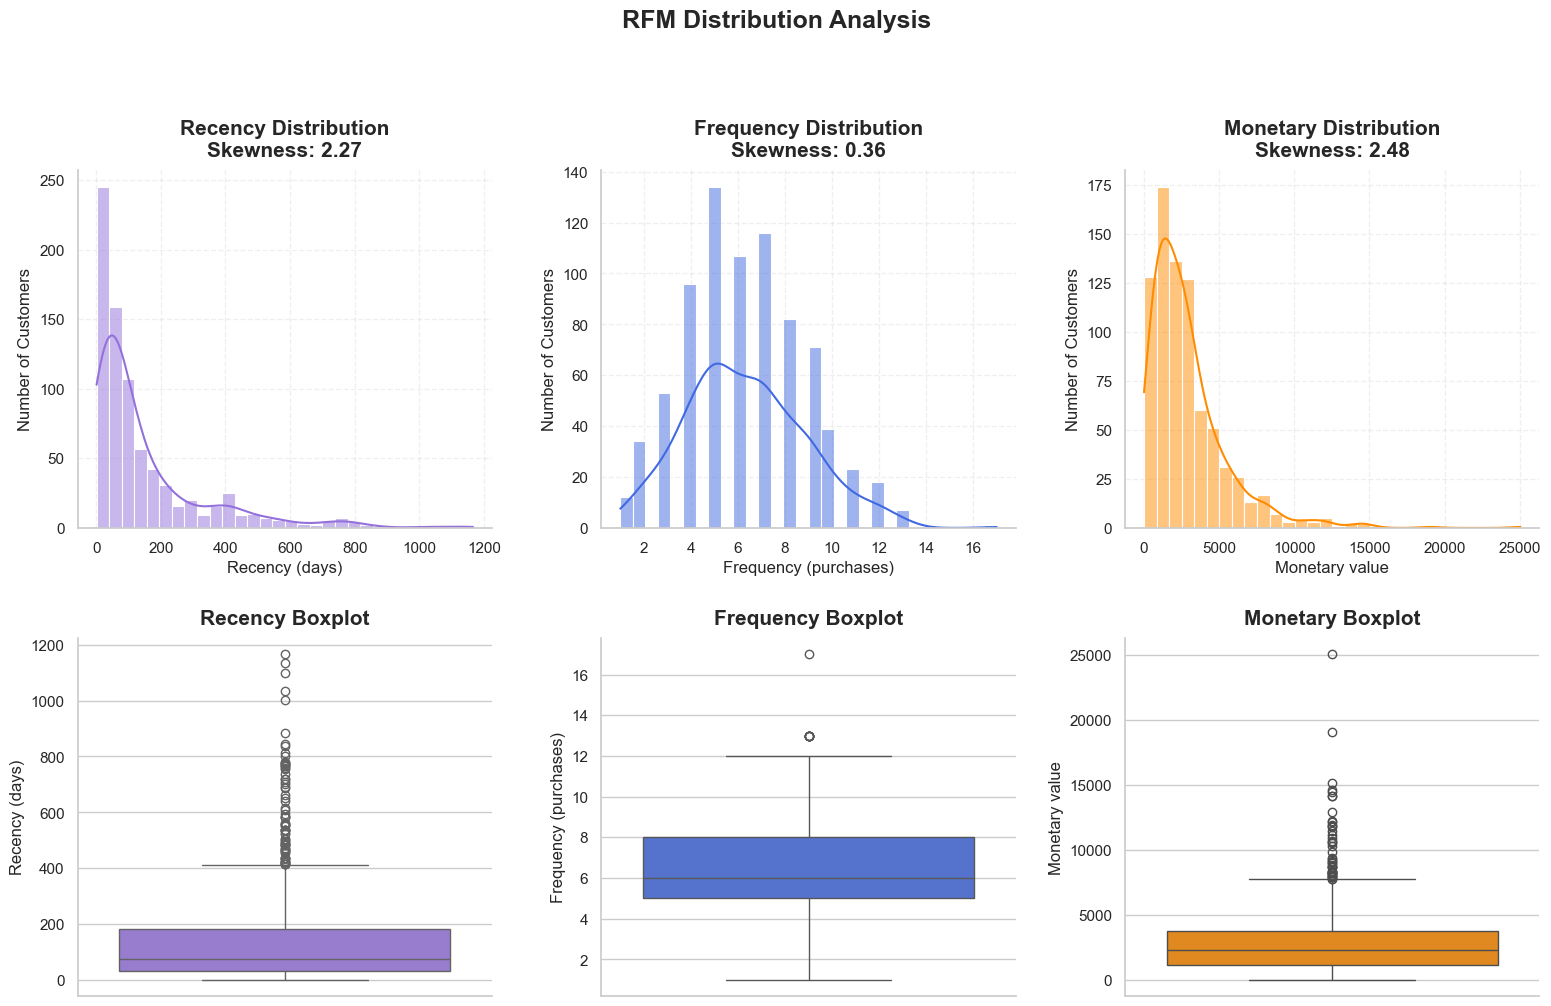

In [396]:
# Compute skewness
skew_vals = rfm[['Recency', 'Frequency', 'Monetary']].skew()
#-------------------------------------------------------------
# Plots
fig, axes = plt.subplots(2, 3)
fig.suptitle('RFM Distribution Analysis', fontsize=18, weight='bold', y=1.02)

# Row 1: Histograms
sns.histplot(rfm['Recency'], kde=True, color=rfm_colors['Recency'], bins=30, ax=axes[0, 0])
axes[0, 0].set_title(f"Recency Distribution\nSkewness: {skew_vals['Recency']:.2f}")
axes[0, 0].set_xlabel('Recency (days)')
axes[0, 0].set_ylabel('Number of Customers')
axes[0, 0].grid(True, linestyle='--', alpha=0.3)

sns.histplot(rfm['Frequency'], kde=True, color=rfm_colors['Frequency'], bins=30, ax=axes[0, 1])
axes[0, 1].set_title(f"Frequency Distribution\nSkewness: {skew_vals['Frequency']:.2f}")
axes[0, 1].set_xlabel('Frequency (purchases)')
axes[0, 1].set_ylabel('Number of Customers')
axes[0, 1].grid(True, linestyle='--', alpha=0.3)

sns.histplot(rfm['Monetary'], kde=True, color=rfm_colors['Monetary'], bins=30, ax=axes[0, 2])
axes[0, 2].set_title(f"Monetary Distribution\nSkewness: {skew_vals['Monetary']:.2f}")
axes[0, 2].set_xlabel('Monetary value')
axes[0, 2].set_ylabel('Number of Customers')
axes[0, 2].grid(True, linestyle='--', alpha=0.3)

# ---------------------------------------------------------------------
# Row 2: Boxplots

sns.boxplot(y=rfm['Recency'], ax=axes[1, 0], color='mediumpurple')
axes[1, 0].set_title('Recency Boxplot')
axes[1, 0].set_ylabel('Recency (days)')

sns.boxplot(y=rfm['Frequency'], ax=axes[1, 1], color='royalblue')
axes[1, 1].set_title('Frequency Boxplot')
axes[1, 1].set_ylabel('Frequency (purchases)')

sns.boxplot(y=rfm['Monetary'], ax=axes[1, 2], color='darkorange')
axes[1, 2].set_title('Monetary Boxplot')
axes[1, 2].set_ylabel('Monetary value')

# Remove unnecessary borders
for ax in axes.flatten():
    sns.despine()

plt.tight_layout(pad=2) # 
# Note: automatic layout adjustment is not sufficient, so plt.tight_layout() is used locally here for better adjustments.

plt.show()

### Insights
The visualizations (histograms and boxplots) visually confirm the distributional patterns previously identified in the descriptive statistics and skewness coefficients.
- **Recency** shows  a pronounced right-skewed distribution, characterized by a concentration of customers with low recency values and a long tail of highly inactive customers. Many outliers are also present, reflecting long periods of customer inactivity.
- **Frequency** appears relatively symmetric with only slight positive skewness, confirming the overall stability and homogeneity of customer purchasing frequency.Only two outliers are present.
- **Monetary** exhibits a strong right-skewed and heavy-tailed distribution with several outliers, where a small subset of high-value customers contributes disproportionately large revenue amounts.

Overall, the visual distributions are consistent with the statistical measures reported earlier, reinforcing the presence of substantial heterogeneity in customer engagement and spending behavior across the dataset.

### 3.4.3. RFM Scatterplots and Correlation Matrix

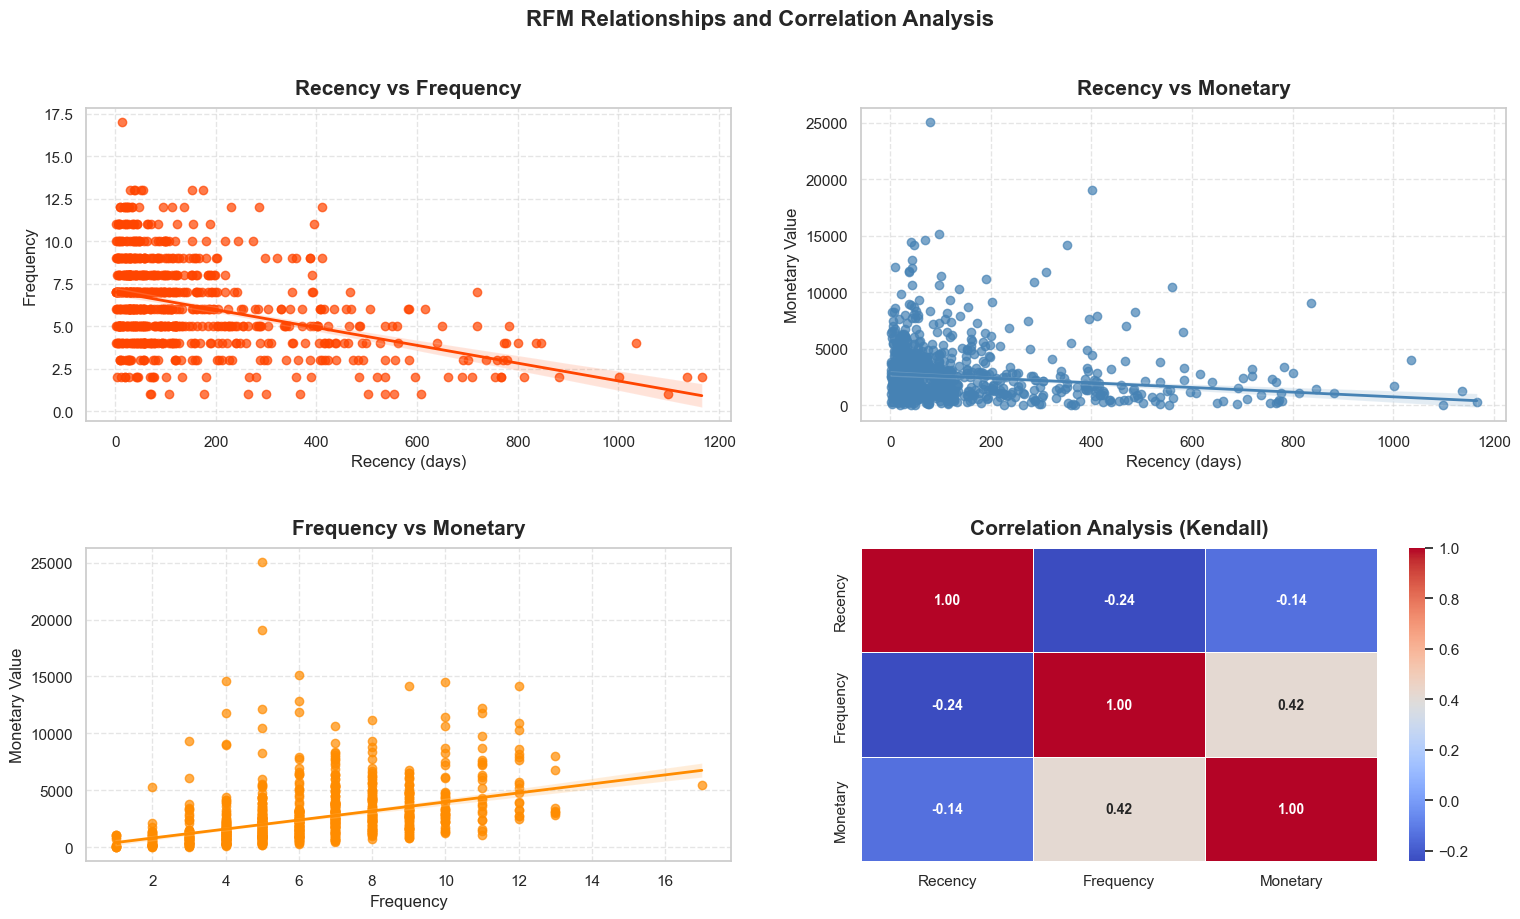

In [397]:
fig, axes = plt.subplots(2, 2)

fig.suptitle('RFM Relationships and Correlation Analysis',fontsize=16,y=0.95,weight='bold')

# -----------------------
# a) Recency vs Frequency
sns.regplot(x='Recency', y='Frequency',data=rfm,ax=axes[0, 0],color='orangered',scatter_kws={'alpha': 0.7},line_kws={'linewidth': 2},robust=True)
axes[0, 0].set_title('Recency vs Frequency')
axes[0, 0].set_xlabel('Recency (days)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)
# Note :robust=True to fit a robust regression that downweights the influence of outliers.
# -----------------------
# b) Recency vs Monetary
sns.regplot(x='Recency', y='Monetary',data=rfm,ax=axes[0, 1],color='steelblue',scatter_kws={'alpha': 0.7},line_kws={'linewidth': 2},robust=True)
axes[0, 1].set_title('Recency vs Monetary')
axes[0, 1].set_xlabel('Recency (days)')
axes[0, 1].set_ylabel('Monetary Value')
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# -----------------------
# c) Frequency vs Monetary
sns.regplot(x='Frequency', y='Monetary',data=rfm,ax=axes[1, 0],color='darkorange',scatter_kws={'alpha': 0.7},line_kws={'linewidth': 2},robust=True)
axes[1, 0].set_title('Frequency vs Monetary')
axes[1, 0].set_xlabel('Frequency')
axes[1, 0].set_ylabel('Monetary Value')
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# -----------------------
# d)Correlation Heatmap
corr_matrix = rfm[['Recency', 'Frequency', 'Monetary']].corr(method='kendall')

sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap='coolwarm',cbar=True,ax=axes[1, 1],annot_kws={'fontsize': 10, 'weight': 'bold'},
            linewidths=0.5,linecolor='white')

axes[1, 1].set_title('Correlation Analysis (Kendall)')

plt.tight_layout(pad=3)
plt.show()


### Insights:

**Recency vs Frequency**
- There is a moderate negative relationship between recency and purchase frequency.
- This reflects a natural behavioral pattern in customer activity: customers who purchased recently tend to buy more frequently, while those who have not purchased in a long time show consistently low engagement. This is expected in retail settings, where active customers remain within an engagement cycle, whereas inactive customers gradually drop out of purchasing behavior over time.
- This pattern is supported by Kendall’s τ = -0.24.

**Recency vs Monetary**
- There is a weak negative relationship between recency and monetary value.
-This indicates that recently active customers tend to contribute slightly more revenue, while long-inactive customers contribute less overall spending.
- However, the weak strength of this relationship suggests that monetary value is not solely determined by recent activity, as some customers may have high historical value but low recent engagement.
- This is confirmed by Kendall’s τ = -0.14.

**Frequency vs Monetary**
- There is a moderate positive relationship between purchase frequency and monetary value.
- Customers who purchase more frequently generate significantly higher revenue, making frequency the strongest RFM driver of customer value.
- This occurs because frequent engagement increases both purchase occasions and cumulative spending, reinforcing the importance of retention and repeat purchase behavior in driving revenue concentration.
- This is Supported by Kendall’s τ = 0.42.

Overall,RFM variables show  only low or moderate correlations, indicating that no single metric fully explains customer behavior.
This suggests that customer value is multi-dimensional and influenced by additional behavioral factors.

## 3.5. Create quantile-based scores (1–5 Scale)

Objective: Convert raw RFM metrics into comparable ordinal scores using quintiles, so customers are ranked relative to the dataset distribution.

Quantile-based scoring was selected because the RFM variables are highly skewed and contain significant outliers.

Using quantiles ensures:
- balanced customer distribution across score groups
- robustness against extreme values
- relative ranking of customers instead of absolute thresholds
- improved comparability between dimensions

A 1–5 scale was used to provide sufficient segmentation granularity while keeping interpretation intuitive.

However, quantile methods have also some limitations. Because quantiles force approximately equal-sized groups, the resulting score boundaries may not always reflect naturally occurring business differences between customers. In addition, score thresholds are relative to the dataset distribution and may shift over time or across industries.

Quantile methods may also compress customers when distributions are highly skewed, particularly for Monetary values, where extreme spenders can still be grouped within the same upper segment.

### 3.5.1. RFM Scoring using Quintile-Based Ranking

In [398]:

# RFM metrics often contain many duplicate values,particularly Frequency and Recency which are naturally discrete variables,
# Direct quantile binning with pd.qcut() can produce errors
# or unstable results due to non-unique bin edges when ties are present.

# To improve stability, we use rank(method='dense'), which assigns
# the same rank to tied values while ensuring a continuous ordinal
# ranking without gaps between ranks.

# This preserves the relative ordering of customer behavior while
# making the data suitable for quantile-based segmentation.

# Scores are assigned on a 1–5 scale:
# 5 = best customers
# 1 = weakest customers

# --------------------------------------------------------------

# a) Recency Score 

rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='dense'),q=5,labels=[5, 4, 3, 2, 1])

# Recency measures how recently a customer made a purchase.
# Lower recency values indicate more recent customer activity,
# which generally reflects stronger engagement.

# Since lower recency is better, the scoring scale is reversed:
# 5 = most recent customers
# 1 = least recent customers

# -----------------------------------------------------------------

# b) Frequency Score 

rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='dense'),q=5,labels=[1, 2, 3, 4, 5])

# Frequency measures how often a customer makes purchases.
# Customers with higher purchase frequency are typically
# more loyal and engaged.

# Therefore:
# 5 = highest purchase frequency
# 1 = lowest purchase frequency


# --------------------------------------------------------------------

# c) Monetary Score 
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='dense'),q=5,labels=[1, 2, 3, 4, 5])

# Monetary measures the total amount spent by each customer.
# Higher monetary values indicate greater revenue contribution.

# Therefore:
# 5 = highest spending customers
# 1 = lowest spending customers

# --------------------------------------------------------------------------
rfm['R_Score']=rfm['R_Score'].astype(int)
rfm['F_Score']=rfm['F_Score'].astype(int)
rfm['M_Score']=rfm['M_Score'].astype(int)
# Since the  R_score, F_score, and M_score obtained from qcut are stored as categorical data types,
# I convert them to numeric types for arithmetic operations.

#------------------------------------------------------------------------------
rfm[['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score']].head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,AA-10315,185,5,5563.560,2,2,5
1,AA-10375,20,9,1056.390,5,5,2
2,AA-10480,260,4,1790.512,1,1,3
3,AA-10645,56,6,5086.935,3,3,5
4,AB-10015,417,3,886.156,1,1,1


### 3.5.2. Compute Composite RFM Score and Total Score

In [399]:
# a) Total RFM Score (Numerical Representation)
# Objective: Provide an overall measure of customer value (range depends on scoring scale)
rfm['RFM_Score_Total'] = rfm['R_Score'] + rfm['F_Score']+ rfm['M_Score']

# b) Composite RFM Score (String Representation)
# Objective: Combine scores into a single code for easy pattern-based segmentation. Example: "555" → top customers across all dimensions

# Convert to string for concatenation 
rfm['RFM_Score_String'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Note:
# This formulation assumes equal importance of Recency, Frequency, and Monetary. In practice, weights may be adjusted to reflect business priorities.

# Example of a weighted RFM score (if Recency is more important):
# rfm['Weighted_RFM'] = 0.5 * rfm['R_Score'].astype(int) + 0.3 * rfm['F_Score'].astype(int) + 0.2 * rfm['M_Score'].astype(int)
#-------------------------------------------------------------------------------------------------------------------------------
rfm[['Customer ID','RFM_Score_Total','RFM_Score_String']].head()

,Customer ID,RFM_Score_Total,RFM_Score_String
0,AA-10315,9,225
1,AA-10375,12,552
2,AA-10480,5,113
3,AA-10645,11,335
4,AB-10015,3,111


## 3.5.3. Overview on RFM Customer Segmentation approach

Customer segmentation can be performed using different analytical approaches, each offering distinct advantages and limitations. The most commonly used methods include traditional RFM analysis, rule-based RFM segmentation, and machine learning-based clustering techniques.

**a) Traditional RFM Framework**

The traditional RFM framework segments customers by scoring them based on Recency, Frequency, and Monetary value. Scores are typically derived using quantile-based discretization or predefined business thresholds, resulting in combined RFM scores (e.g., 555 → Champions).

Advantages:
- Simple and easy to implement
- Highly interpretable and intuitive
- Widely used in marketing and customer analytics

Limitations:
- Relies on rigid and uniform scoring rules
- May oversimplify complex customer behavior
- Limited flexibility for adapting to specific business strategies
  
**b) Rule-Based RFM Segmentation**

Rule-based RFM segmentation extends the traditional RFM framework by applying explicit, business-defined rules to assign customers into predefined segments based on their Recency, Frequency, and Monetary scores.

For example, a rule such as R ≥ 4, F ≥ 4, and M ≥ 4 → Champions directly assigns customers to a segment according to predefined business logic. These rules are designed using domain knowledge, strategic objectives, and observed customer behavior patterns.

Advantages:
- Fully transparent and highly interpretable
- Flexible and customizable to business requirements
- Strong alignment with marketing, CRM, and retention strategies

Limitations:
- Requires domain expertise to design meaningful rules
- May introduce subjectivity in segmentation design
- Less suitable when segmentation requires highly granular or complex rule interactions

**c)  Machine Learning-Based Segmentation (Clustering)**

Machine learning approaches such as K-Means or hierarchical clustering group customers based on similarity patterns in the data, without requiring predefined rules or labels.

Advantages:
- Captures hidden patterns and non-linear relationships in data
- Scales effectively to large datasets
- Reduces reliance on manual rule design

Limitations:
- Less interpretable than rule-based methods
- Requires parameter tuning (e.g., number of clusters)
- Results may vary depending on initialization and dataset characteristics


**Why Rule-Based RFM is Used in This Project**

In this project, a rule-based RFM segmentation approach is adopted due to its strong balance between interpretability and business applicability. 
It enables a direct translation of customer behavioral patterns into actionable meaningful business segments.

The rules used here are inspired by segmentation practices commonly used across marketing and business intelligence platforms to categorize customers into segments.

To implement these rules, an if-else structure or np.select() function is used, following a hierarchical first-match classification logic. This means each customer is assigned to the first segment whose conditions they satisfy, based on a predefined order of priority.

Therefore, the ordering of rules is intentional and plays a critical role in the segmentation design, ensuring that higher-priority or higher-value segments are consistently assigned and clearly separated from lower-priority groups.


In [400]:
# Rule-Based RFM Segmentation

# --------------------------------------------------------
# Customer segments are assigned using np.select(), which  is a more efficient alternative to row-wise apply() functions with if/elif conditions.

# -------------------------------------------------------
# 1. Extract RFM score series for readability
r = rfm['R_Score']
f = rfm['F_Score']
m = rfm['M_Score']


# ------------------------------------------------------
# 2. Define segmentation rules

conditions = [

    # High-value and highly engaged customers
    (r >= 4) & (f >= 4) & (m >= 4),                    # Champions
    (r >= 3) & (f >= 4) & (m >= 3),                    # Loyal Customers

    # Previously valuable customers showing churn risk
    (r == 1) & (m >= 4),                               # Can't Lose Them
    (r == 2) & (m >= 4),                               # At Risk

    # Recently active customers with growth potential
    ((r == 4) | (r == 5)) & ((f == 2) | (f == 3)),    # Potential Loyalists
    (r == 5) & (f == 1),                               # New Customers
    (r == 3) & (f == 3),                               # Need Attention
    ((r == 3) | (r == 4)) & (f <= 2),                  # Promising

    # Active but lower-value customers
    (r >= 3) & (f >= 4) & (m <= 2),                    # Active Low-Spenders

    # Low-engagement and inactive customers
    (r == 2) & (m <= 3),                               # About to Sleep
    (r == 1) & ((f >= 3) | (m == 3))                   # Hibernating
]


# ------------------------------------------------------------
# 3. Define segment labels
# Labels are mapped positionally to the conditions above
choices = [
    'Champions',
    'Loyal Customers',
    "Can't Lose Them",
    'At Risk',
    'Potential Loyalists',
    'New Customers',
    'Need Attention',
    'Promising',
    'Active Low-Spenders',
    'About to Sleep',
    'Hibernating'
]

# --------------------------------------------------------------
# 4. Assign customer segments
# Note: Customers not matching any rule are classified as 'Lost'
rfm['Segment'] = np.select(conditions, choices,default='Lost')

rfm.head()

,Customer ID,LastPurchaseDate,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score_Total,RFM_Score_String,Segment
0,AA-10315,2024-06-29,185,5,5563.560,2,2,5,9,225,At Risk
1,AA-10375,2024-12-11,20,9,1056.390,5,5,2,12,552,Active Low-Spenders
2,AA-10480,2024-04-15,260,4,1790.512,1,1,3,5,113,Hibernating
3,AA-10645,2024-11-05,56,6,5086.935,3,3,5,11,335,Need Attention
4,AB-10015,2023-11-10,417,3,886.156,1,1,1,3,111,Lost


###

# 4. Customer Segment and Revenue Analysis<a id="segment-and-revenue-analysis"></a>

## 4.1. Customer Segment Analysis

This section aims to analyze customer segments obtained from RFM segmentation by examining their distribution, average behavioral profiles, and internal variability. The purpose is to better understand customer value structure and support data-driven marketing decisions.

### 4.1.1. Segment Distribution Bar Chart

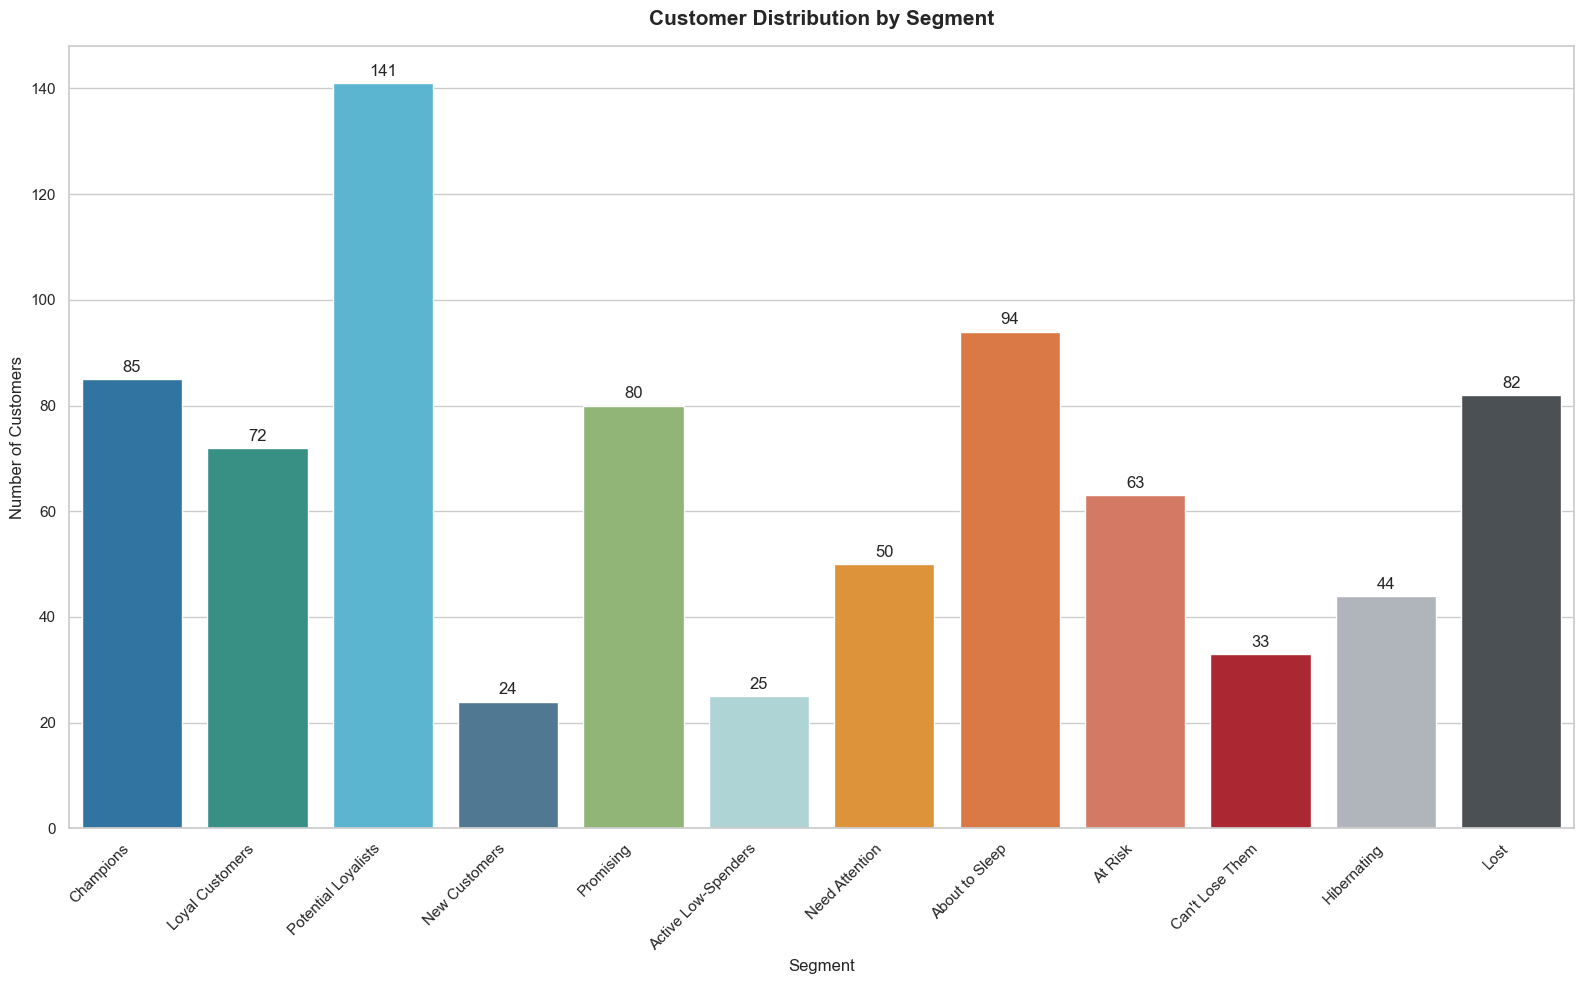

In [401]:
# Natural order for the RFM segments
segment_order = [
    'Champions', 'Loyal Customers', 'Potential Loyalists', 'New Customers', 
    'Promising', 'Active Low-Spenders', 'Need Attention', 'About to Sleep', 
    'At Risk', "Can't Lose Them", 'Hibernating', 'Lost']
#-----------------------------------------------------------------------------
fig, ax = plt.subplots()

# Count the frequency of each segment
segment_counts = rfm['Segment'].value_counts()

# Generate the bar plot using the specified order
sns.barplot( x=segment_counts.index,  y=segment_counts.values,hue=segment_counts.index, palette=segment_palette,order=segment_order,legend=False, ax=ax)

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Formatting and text elements
plt.title('Customer Distribution by Segment', pad=15)
plt.xlabel('Segment')
plt.ylabel('Number of Customers')

# Adjusted rotation and alignment to prevent long labels from cutting off
plt.xticks(rotation=45, ha='right')

plt.show()

### Insights:
- Champions (85) and Loyal Customers (72) form a solid, high-value base driving stable revenue.
- Potential Loyalists (141) are the largest segment and key for upselling and conversion into loyal/high-value customers.
- About to Sleep (94), At Risk (63), and Can’t Lose Them (33) signal immediate retention priorities, especially the high-value “Can’t Lose Them” group.
- Hibernating (44) and Lost (82) show a sizeable inactive base (126 customers) requiring low-cost win-back strategies.
- Low numbers in New Customers (24) and Promising (80) suggest weak onboarding or acquisition flow.

Overall: strong loyal base, high mid-tier potential, but noticeable churn pressure and limited new customer inflow.

### 4.1.2. Heatmap — Average RFM by Segment

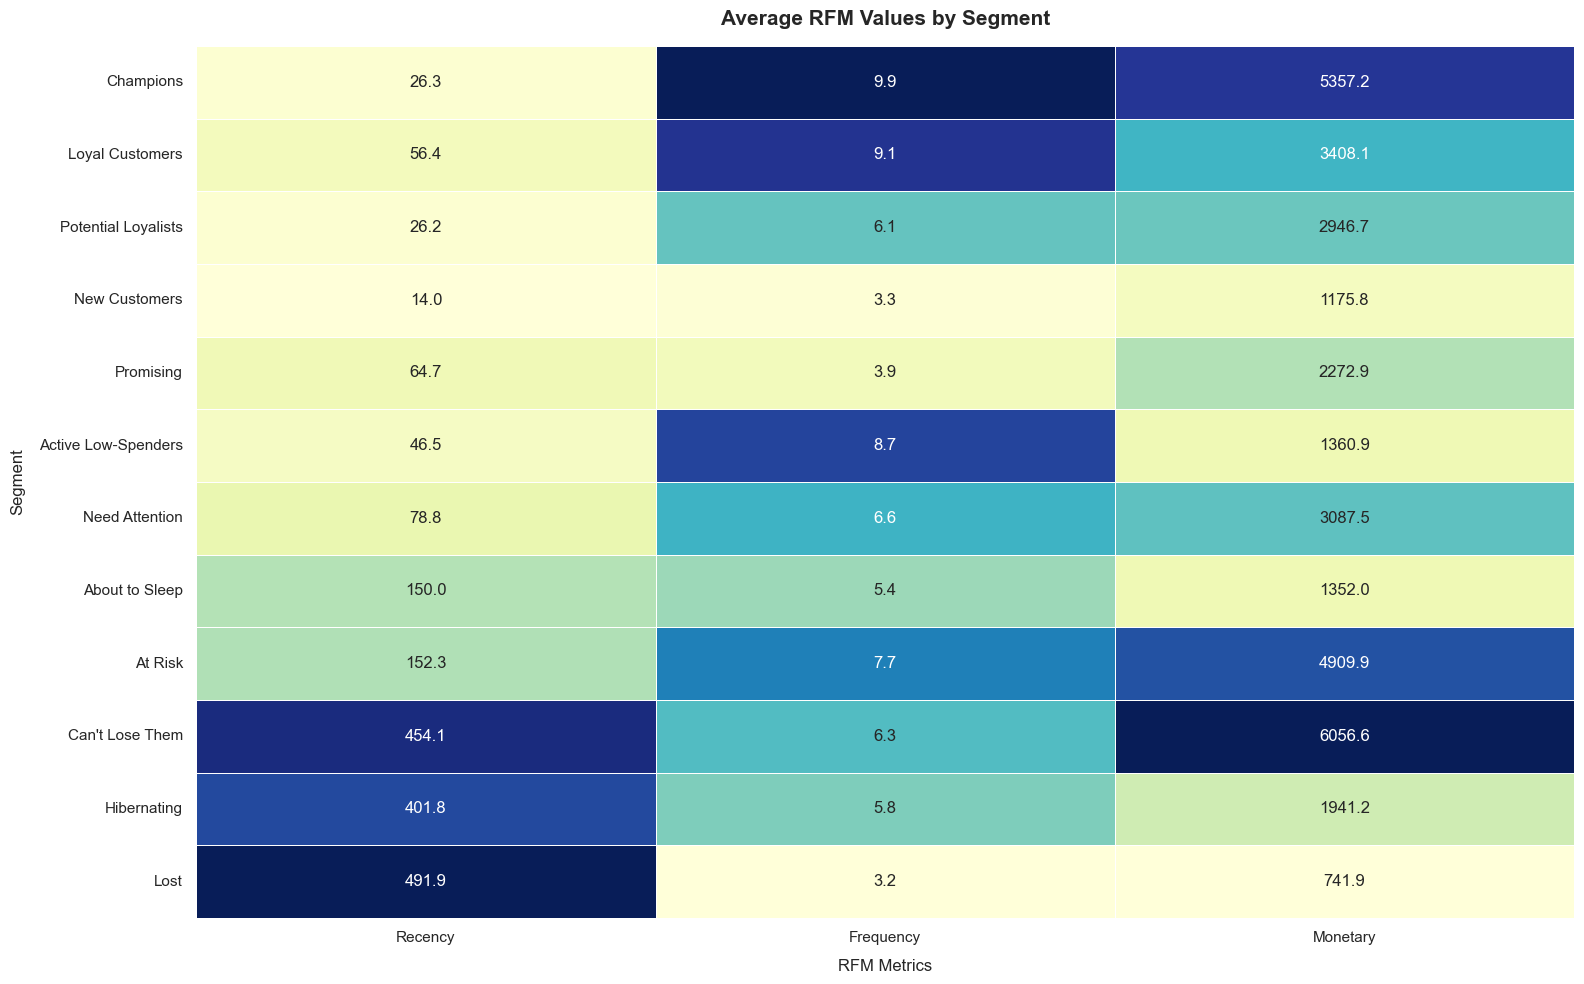

In [402]:
# Define business segment order
segment_order = [
    'Champions', 'Loyal Customers', 'Potential Loyalists', 'New Customers', 
    'Promising', 'Active Low-Spenders', 'Need Attention', 'About to Sleep', 
    'At Risk', "Can't Lose Them", 'Hibernating', 'Lost']
#---------------------------------------------------------------------------
# Compute average RFM values per segment
heatmap_data = rfm.groupby('Segment', observed=True)[['Recency', 'Frequency', 'Monetary']].mean()

# Reindex the dataframe to enforce logical order
heatmap_data = heatmap_data.reindex(segment_order)

# Normalize columns individually (since the data has different scale)
heatmap_data_normalized = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())
#-------------------------------------

# Plot
fig, ax = plt.subplots()
sns.heatmap(heatmap_data_normalized,annot=heatmap_data ,fmt=".1f",cmap="YlGnBu",linewidths=0.5,cbar=False,ax=ax)
# Note: 
    # - the scaled values (0–1) in heatmap_data_normalized are used for the  heatmap colors
    #  the original values in heatmap_data  are used  in 'annot parameter' as labels for business interpretation

# Title and labels
ax.set_title('Average RFM Values by Segment', pad=15)
ax.set_xlabel('RFM Metrics', labelpad=10)
ax.set_ylabel('Segment', labelpad=10)

plt.show()

### Insights

**High-value and highly engaged customers (157 customers | 19.8%)**

**a. Champions (85)**
- Recency: ~26 days (very recent)
- Frequency: ~9.9 (very high)
- Monetary: ~5,357 (very high)

Champions are the highest-value customer segment, combining very recent activity, extremely high purchase frequency, and top-tier spending. They are the primary revenue drivers and represent the strongest foundation of customer lifetime value.

**b. Loyal Customers (72)**
- Recency: ~56 days (recent)
- Frequency: ~9.1 (very high)
- Monetary: ~3,408 (high)

Loyal Customers are highly consistent repeat buyers with strong engagement levels. While their monetary value is lower than Champions, they represent a stable and reliable revenue base and are critical for long-term retention-driven growth.

---

**Previously valuable customers showing churn risk (96 customers | 12.1%)**

**a. Can't Lose Them (33)**
- Recency: ~454 days (very inactive)
- Frequency: ~6.3 (moderate)
- Monetary: ~6,057 (very high)

These are high-value customers who were previously among the most profitable but have become inactive. They represent the highest revenue recovery potential, even though reactivation probability is lower.

**b. At Risk (63)**
- Recency: ~152 days (inactive)
- Frequency: ~7.7 (high)
- Monetary: ~4,910 (high)

At Risk customers still show strong historical value and engagement, but recent inactivity signals early churn behavior. This is a critical segment for immediate retention interventions.

---
**Recently active customers with growth potential (295 customers | 37.2%)**

**a. Potential Loyalists (141)**
- Recency: ~26 days (very recent)
- Frequency: ~6.1 (moderate)
- Monetary: ~2,947 (moderate)

Potential Loyalists are highly promising customers who have recently engaged and already show solid purchasing behavior. With targeted engagement, they can be converted into Loyal Customers or Champions.

**b. New Customers (24)**
- Recency: ~14 days (very recent)
- Frequency: ~3.3 (low)
- Monetary: ~1,176 (low)

New Customers are in the early lifecycle stage. The main objective is activation and encouraging second purchases to build early loyalty.

**c. Need Attention (50)**
- Recency: ~79 days (moderately recent)
- Frequency: ~6.6 (moderate)
- Monetary: ~3,087 (moderate–high)

These customers still hold strong value but show early signs of disengagement. Without intervention, they risk transitioning into churn-risk segments.

**d. Promising (80)**
- Recency: ~65 days (moderately recent)
- Frequency: ~3.9 (low)
- Monetary: ~2,273 (moderate)

Promising customers show early-stage value but inconsistent purchasing behavior. Their growth depends primarily on increasing engagement frequency.

---
**Active but lower-value customers (25 customers | 3.2%)**

**Active Low-Spenders (25)**
- Recency: 46.5(recent–moderate)
- Frequency: ~8.7 (very high)
- Monetary: ~1,361 (low)

Active Low-Spenders are highly engaged in terms of frequency but contribute low revenue per customer. They present strong upselling and bundling opportunities to increase average order value.

---
**Low engagement and inactive customers (138 customers | 17.4%)**

**a. About to Sleep (94)**
- Recency: ~150 days (inactive)
- Frequency: ~5.4 (moderate)
- Monetary: ~1,352 (low)

These customers are transitioning toward churn, showing declining activity after previously moderate engagement. Reactivation campaigns are essential to prevent full loss.

**b. Hibernating (44)**
- Recency: ~402 days (very inactive)
- Frequency: ~5.8 (moderate)
- Monetary: ~1,941 (low–moderate)

Hibernating customers have long been inactive and offer limited short-term value. They are low priority for reactivation unless low-cost campaigns are used.

---
**Lost (82 customers | 10.3%)**
- Recency: ~492 days (very inactive)
- Frequency: ~3.2 (low)
- Monetary: ~742 (low)

Lost customers are fully churned with low historical value. Compared to other inactive segments, they offer minimal expected return from reactivation efforts.

---
**Conclusion**

The customer base shows a clear structure:
- 19.8% High-value customers drive the majority of revenue stability
- 37.2% Growth segments represent the main expansion opportunity
- ~30% churn-risk and inactive customers highlight a strong retention challenge
- 3.2% active low-spenders present efficient upsell potential

 Overall, the business is strongly growth-oriented, but long-term performance depends heavily on retention of high-value customers and conversion of growth segments into loyalty tiers.

### 4.1.3. Boxplots by dimension and Segment

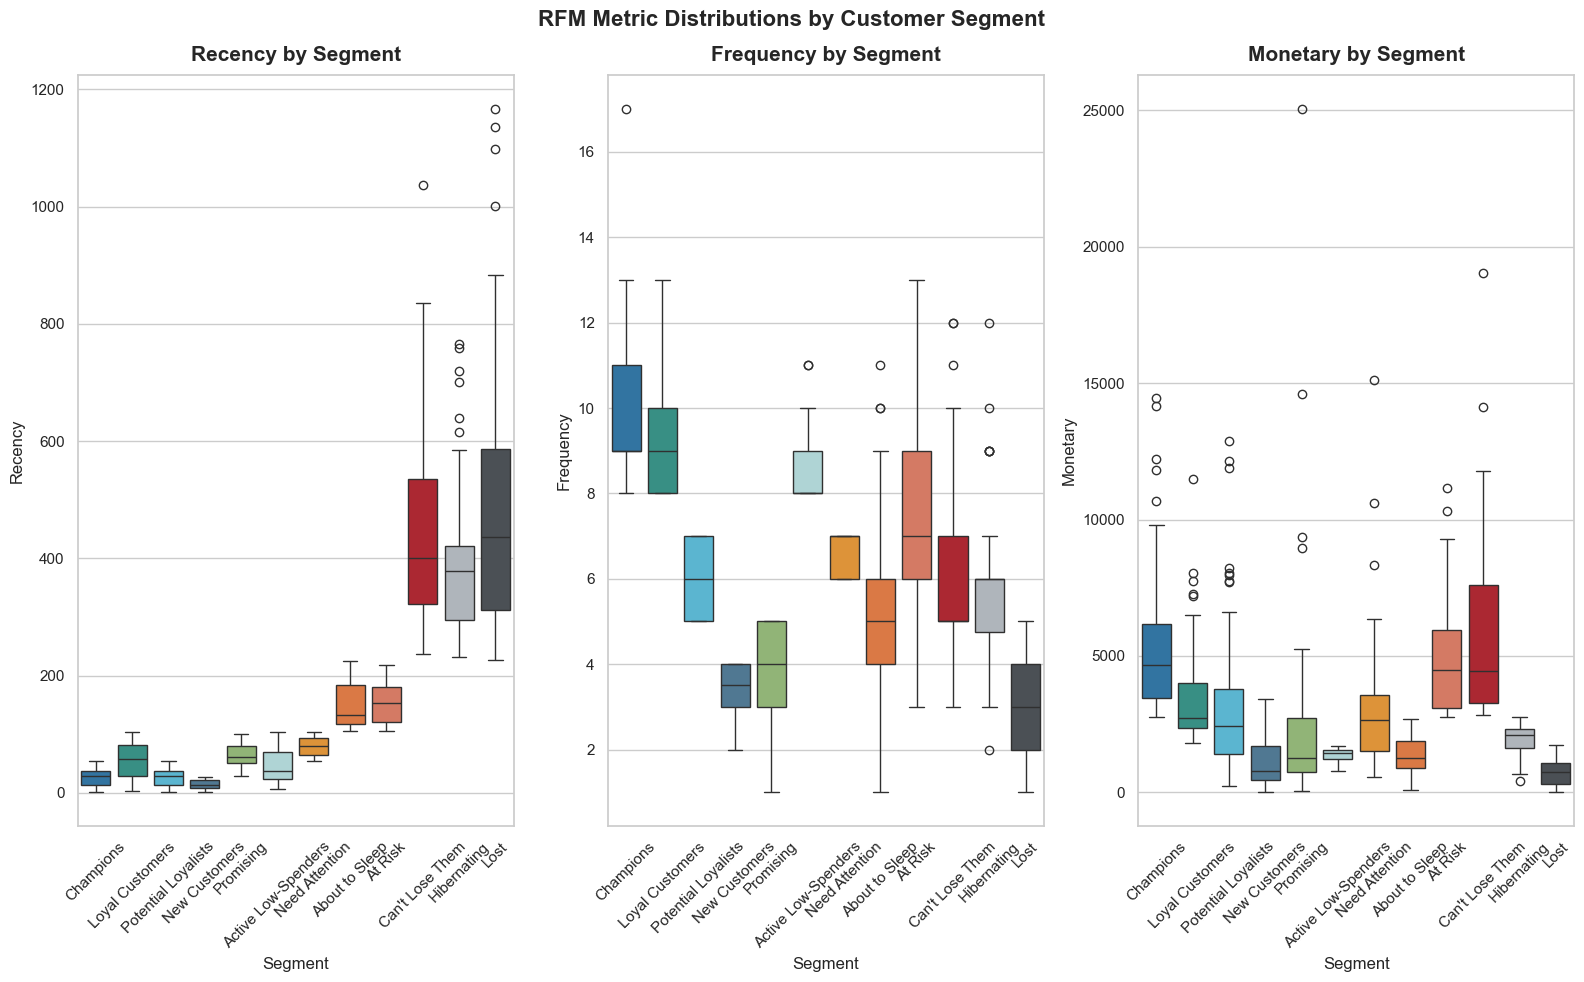

In [403]:
fig, axes = plt.subplots(1, 3)
fig.suptitle('RFM Metric Distributions by Customer Segment', fontsize=16,fontweight='bold')

# Segment Ordering
segment_order = [
    'Champions', 
    'Loyal Customers', 
    'Potential Loyalists', 
    'New Customers', 
    'Promising', 
    'Active Low-Spenders',
    'Need Attention', 
    'About to Sleep', 
    'At Risk', 
    "Can't Lose Them", 
    'Hibernating', 
    'Lost'
]
# -----------------------  
# Recency
sns.boxplot(data=rfm,x='Segment',y='Recency',hue='Segment',order=segment_order, ax=axes[0],palette=segment_palette,legend=False)
axes[0].set_title('Recency by Segment')
axes[0].tick_params(axis='x', rotation=45)

# -----------------------
# Frequency
sns.boxplot(data=rfm,x='Segment',y='Frequency',hue='Segment',order=segment_order,ax=axes[1],palette=segment_palette,legend=False)
axes[1].set_title('Frequency by Segment')
axes[1].tick_params(axis='x', rotation=45)

# -----------------------
# Monetary
sns.boxplot(data=rfm,x='Segment',y='Monetary',hue='Segment',order=segment_order,ax=axes[2],palette=segment_palette,legend=False)
axes[2].set_title('Monetary by Segment')
axes[2].tick_params(axis='x', rotation=45)

plt.show()

### Insights:

**Recency**
- Champions, Loyal Customers, Potential Loyalists and New Customers  show consistently low recency, indicating strong recent engagement.
- Recency variability increases sharply from the About to Sleep segment onward, highlighting growing churn risk.
- Can’t Lose Them, Hibernating, and Lost customers exhibit the longest inactivity periods,with some exceeding 1,000 days.

**Frequency**
- Champions maintain the highest and most stable purchase frequency across all segments.
- Loyal Customers also demonstrate strong repeat purchasing behavior.
- New Customers, Promising and Lost customers remain concentrated at low frequency levels, suggesting limited repeat purchasing.
  
**Monetary**
- Champions and "Can’t Lose Them" drive the highest monetary distributions, representing the most valuable customer assets.
- "At Risk" and "Can’t Lose Them" customers still generate relatively high monetary value despite declining engagement, making them critical retention targets.
-  Monetary distributions are heavily right-skewed across almost all segments, with significant high-spending outliers peaking between 15,000 and 25,000.



## 4.2. Revenue Analysis

In [404]:
### 4.2.1. Revenue Concentration (Pareto Analysis)

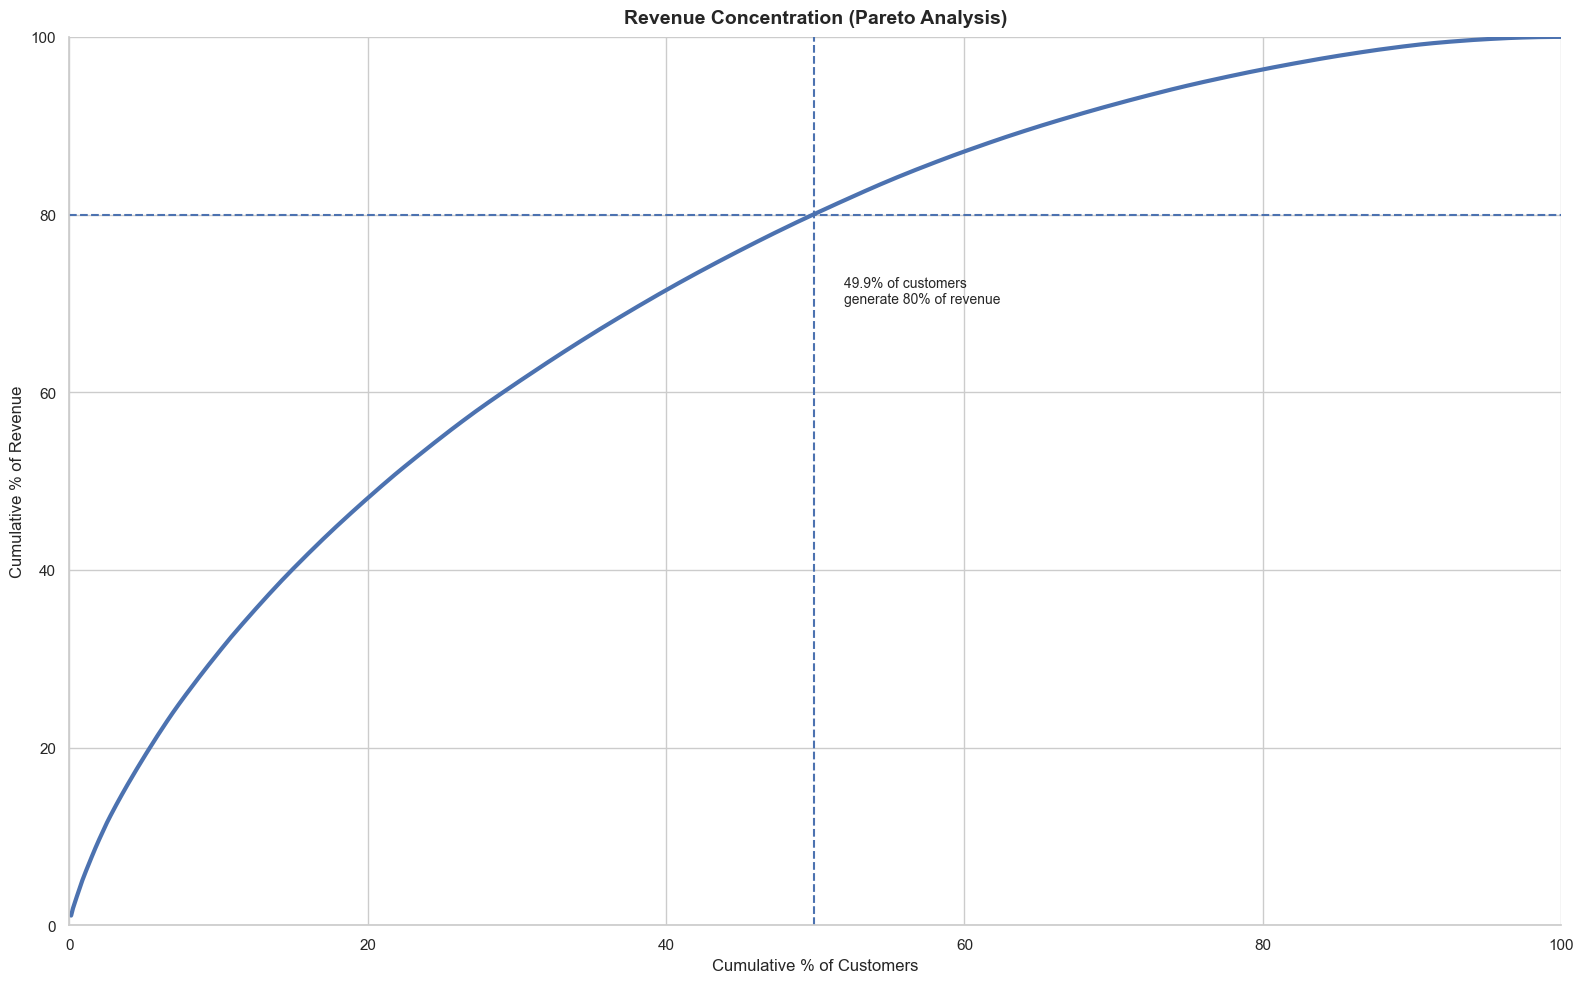

In [405]:
# Objective: Analyze how revenue is distributed across customers and determine whether a small group of customers contributes a large share of total revenue.

# Step 1: Sort customers by Monetary value (highest first)
rfm_sorted = (rfm.sort_values('Monetary', ascending=False).reset_index())

# Step 2: Compute cumulative revenue
rfm_sorted['Cumulative_Revenue'] = (rfm_sorted['Monetary'].cumsum())

# Step 3: Compute cumulative revenue percentage (cumulative revenue as a percentage of total revenue)
rfm_sorted['Cumulative_Revenue_Pct'] = (rfm_sorted['Cumulative_Revenue']/ rfm_sorted['Monetary'].sum()) * 100

# Step 4: Compute cumulative customer percentage
rfm_sorted['Customer_Pct'] = ((rfm_sorted.index + 1)/ len(rfm_sorted))*100

# Step 5: Identify the Pareto point (80% revenue)
# That is,the first customer position (index) where cumulative revenue reaches or exceeds 80%.
pareto_idx = np.argmax((rfm_sorted['Cumulative_Revenue_Pct'] >= 80)) 

# An equivalent pandas version : pareto_idx = (rfm_sorted['Cumulative_Revenue_Pct'] >= 80).idxmax()
# N.B: np.argmax() always returns the integer position of the first maximum value, while idxmax() returns the index label of the first maximum value.

# Retrieve the corresponding customer percentage.
pareto_customer_pct = rfm_sorted.loc[pareto_idx,'Customer_Pct']
#----------------------------------------
# Step 6: Visualization

plt.figure()

# Plot cumulative revenue curve
sns.lineplot(data=rfm_sorted,x='Customer_Pct',y='Cumulative_Revenue_Pct',linewidth=3)

# Add Pareto reference lines
   # Horizontal line at 80% revenue
plt.axhline(y=80,linestyle='--')

   # Vertical line showing customer percentage required to generate 80% of revenue.
plt.axvline( x=pareto_customer_pct, linestyle='--')

# Add annotation
plt.text(x=pareto_customer_pct + 2, y=70, s=f'{pareto_customer_pct:.1f}% of customers\ngenerate 80% of revenue',fontsize=10)
# Note: If we use x = pareto_customer_pct and y = 80, the text overlaps with the horizontal reference line and the curve, making it harder to read.
# To improve readability, we adjust the position:
# - x-position: pareto_customer_pct + 2 → shifts the text slightly to the right of the vertical Pareto line for better spacing.
# - y-position: 70 → places the annotation below the 80% line, avoiding overlap with the reference line and curve.

# Labels, title and Axis limits 
plt.xlabel('Cumulative % of Customers')
plt.ylabel('Cumulative % of Revenue')
plt.title('Revenue Concentration (Pareto Analysis)',fontsize=14,weight='bold')
plt.xlim(0, 100)
plt.ylim(0, 100)

# Remove borders
sns.despine()

plt.show()

### Insights:
- Approximately 50% of customers generate 80% of total revenue, indicating a moderate level of revenue concentration across the base.
- The top 20% of customers contribute around 50% of revenue, confirming that higher-spending customers still drive a disproportionate share of value, but not in an extreme skewed pattern.
- This indicates a partial Pareto distribution, where revenue concentration exists but is more balanced than a strict 80/20 rule.

Overall, revenue is moderately concentrated, with meaningful contribution from both top-tier and mid-tier customers rather than being heavily dependent on a small elite segment.

### 4.2.2. Revenue Contribution by Segment

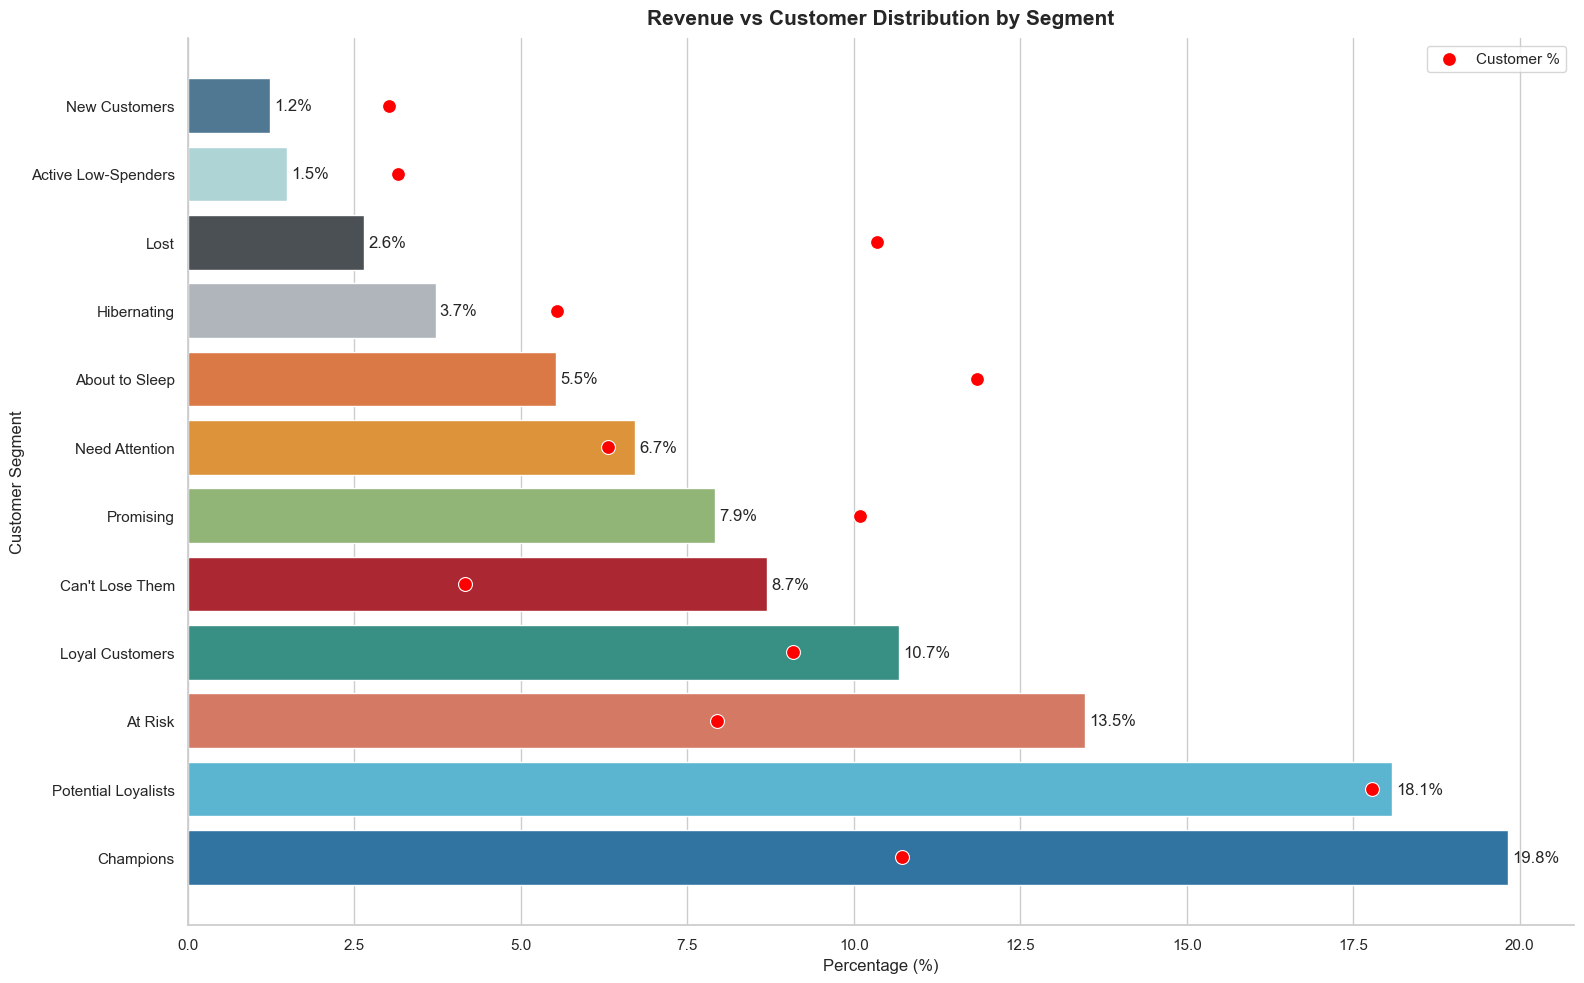

In [406]:
# Objective: Analyze how total revenue is distributed across RFM segments to identify which customer groups drive the most value.

# Aggregate revenue and customer count per segment
segment_summary = (rfm.groupby('Segment',observed=True, as_index=False).agg(Monetary=('Monetary', 'sum'),Customer_Count=('Segment', 'count')))

# Compute revenue contribution percentage
segment_summary['Revenue_Pct'] = (segment_summary['Monetary']/ segment_summary['Monetary'].sum()) * 100

# Compute customer distribution percentage
segment_summary['Customer_Pct'] = (segment_summary['Customer_Count']/ segment_summary['Customer_Count'].sum()) * 100

# Sort by revenue contribution for better readability
segment_summary = segment_summary.sort_values('Revenue_Pct', ascending=True)

#---------------------------------------

fig, ax = plt.subplots()

# Revenue contribution bars
sns.barplot( data=segment_summary, x='Revenue_Pct', y='Segment', hue='Segment', palette=segment_palette, dodge=False, legend=False, ax=ax)

# Overlay customer distribution points
sns.scatterplot(data=segment_summary,x='Customer_Pct',y='Segment',color='red',s=100,label='Customer %',ax=ax)

# Add titles and labels
ax.set_title('Revenue vs Customer Distribution by Segment', weight='bold')
ax.set_xlabel('Percentage (%)')
ax.set_ylabel('Customer Segment')

# Add labels only to bar containers
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

# Display legend
plt.legend()

#  Remove borders
sns.despine()

plt.show()

### Insights

**a) Segments generating higher revenue relative to customer share**
- **Champions**: 10.7% of customers → 19.8% of total revenue
- **At Risk**: 7.9% of customers → 13.5% of total revenue
- **Can't Lose Them**: 4.2% of customers → 8.7% of total revenue

These segments form the core profitability engine of the business. Despite representing a relatively small share of the customer base, they contribute a disproportionately large portion of total revenue. Retention and reactivation efforts should therefore be strategically prioritized for these high-value customers.

**b) Segments with balanced customer and revenue contribution**
- **Loyal Customers**: `9.1%` of customers → `10.7%` of total revenue
- **Potential Loyalists**: `17.8%` of customers → `18.1%` of total revenue
- **Need Attention**: `6.3%` of customers → `6.7%` of total revenue

These segments demonstrate balanced engagement and revenue contribution, making them strong long-term growth opportunities. With targeted retention, loyalty, and engagement strategies, they have significant potential to evolve into higher-value customer groups.

**c) Segments generating lower revenue relative to customer share**
- **Promising**: `10.1%` of customers → `7.9%` of total revenue
- **About to Sleep**: `11.9%` of customers → `5.5%` of total revenue
- **Hibernating**: `5.5%` of customers → `3.7%` of total revenue
- **Lost**: `10.3%` of customers → `2.6%` of total revenue
- **Active Low-Spenders**: 3.2% of customers → 1.5% of total revenue
- **New Customers**: `3.0%` of customers → `1.2%` of total revenue

These segments contribute relatively limited revenue compared to their population size. As a result, cost-efficient engagement approaches such as automation, upselling, selective retention campaigns, and low-cost reactivation strategies are more appropriate than resource-intensive interventions.

---
However, it is important to note that monetary value does not necessarily equate to profitability.
While high-monetary customers contribute significantly to revenue, they may not always represent the most profitable segments. In practice, high-spending customers can also:
- benefit from heavy discounts or promotions,
- generate higher return or refund rates,
- or require greater servicing and operational costs.

As a result, revenue-based segmentation should be interpreted with caution, as it does not fully capture net profitability or customer lifetime value.

###


#  5. Conclusions and  Actionable business recommendations <a id="conclusions-and-actionable-business-recommendations">

## 5.1. Conclusion

The RFM segmentation analysis reveals a moderately balanced revenue structure, with clear differences in customer value, engagement, and churn risk.

The Pareto analysis indicates that approximately half of the customer base generates around 80% of total revenue. This reflects a moderate level of revenue concentration, suggesting that revenue is not overly dependent on a very small group of customers. Instead, value is distributed across a broader base of high- and mid-value customers, reducing overall business risk.

High-value segments such as Champions and Loyal Customers remain the primary revenue contributors due to their strong engagement and consistent purchasing behavior. However, their contribution is supported by a meaningful number of additional customers rather than being overly concentrated in a small elite group.

At the same time, segments such as Potential Loyalists, New Customers, and Promising indicate strong acquisition performance and represent a key opportunity to further expand the high-value customer base through targeted engagement and conversion strategies.

Finally, lower-engagement segments such as At Risk, About to Sleep, and Hibernating highlight areas of churn risk that require proactive retention efforts to prevent gradual revenue erosion.

Overall, the business demonstrates a healthy and resilient customer structure, combining a strong revenue-generating core with a substantial growth pipeline and manageable dependency risk.

## 5.2. Recommendations
The following table summarizes the recommended business strategy for each customer segment based on customer value, engagement level, and churn risk.
| Segment                 | Business Objective                       | Recommended Actions                                                                                        |
| ----------------------- | ---------------------------------------- | ---------------------------------------------------------------------------------------------------------- |
| **Champions**           | Retain and maximize high-value customers | VIP programs, exclusive rewards, early access, and advocacy initiatives to sustain engagement and loyalty. |
| **Loyal Customers**     | Strengthen long-term retention           | Personalized offers, loyalty benefits, and cross-selling to increase lifetime value.                       |
| **Potential Loyalists** | Convert into loyal customers             | Targeted campaigns, personalized recommendations, and engagement-driven incentives.                        |
| **New Customers**       | Accelerate activation                    | Onboarding journeys, welcome offers, and guided product discovery to drive first repeat purchase.          |
| **Promising**           | Build engagement consistency             | Tailored promotions and behavioral triggers to increase purchase frequency.                                |
| **Need Attention**      | Prevent early disengagement              | Re-engagement campaigns and personalized reminders to restore activity.                                    |
| **Active Low-Spenders** | Increase customer value                  | Upselling, bundling, and cross-selling to improve average order value.                                     |
| **At Risk**             | Prevent churn of valuable customers      | Proactive retention campaigns and personalized win-back incentives.                                        |
| **Can't Lose Them**     | Recover high historical value            | High-priority retention efforts and strong personalized offers to re-engage key customers.                 |
| **About to Sleep**      | Reactivate declining customers           | Time-sensitive offers and personalized reminders before full disengagement.                                |
| **Hibernating**         | Low-cost reactivation testing            | Automated, low-cost campaigns to test re-engagement potential.                                             |
| **Lost**                | Minimize unnecessary retention spend     | Limit marketing investment; focus only on low-cost or scalable reactivation efforts.                       |


## 5.3. Strategic Priorities

Based on the segmentation results, business actions should be organized around four strategic pillars:

**Retention of high-value customers**
- Champions
- Loyal Customers
- At Risk

Focus on protecting and maximizing the value of existing high-contribution customers through loyalty programs, personalized engagement, and proactive retention strategies.

**Conversion of growth segments**
- Potential Loyalists
- Promising
- New Customers

Prioritize converting early-stage and mid-value customers into loyal buyers through targeted engagement, onboarding journeys, and personalized offers.

**Selective churn recovery**
- Can't Lose Them
- About to Sleep

Implement focused win-back strategies for customers with high historical or near-term value risk, using personalized incentives and time-sensitive campaigns.

**Low-cost maintenance**
- Hibernating
- Lost

Minimize retention costs by using automated, low-cost campaigns only where reactivation potential exists, while avoiding inefficient marketing spend.

While RFM segmentation provides clear, interpretable, and business-oriented customer groups, it remains dependent on predefined rule-based thresholds.
To complement this approach, a K-Means clustering model will be explored in a future phase to identify data-driven customer segments and evaluate the consistency of the behavioral patterns identified through RFM analysis.
Combining interpretable business rules with unsupervised machine learning techniques may provide a more comprehensive understanding of customer behavior and segmentation structure.

# 6. Annex— Segment Descriptive Statistics <a id="annex-segment-descriptive-statistics"> 

### Table A1 — RFM Statistics Summary

In [407]:
segment_order = [
    'Champions', 
    'Loyal Customers', 
    'Potential Loyalists', 
    'New Customers', 
    'Promising', 
    'Active Low-Spenders',
    'Need Attention', 
    'About to Sleep', 
    'At Risk', 
    "Can't Lose Them", 
    'Hibernating', 
    'Lost'
]
# Convert the Segment column to an ordered categorical variable so segments appear in a meaningful business order
rfm['Segment'] = pd.Categorical(rfm['Segment'], categories=segment_order, ordered=True)

# Compute Summary statistics by segment
rfm.groupby('Segment', observed=True)[['Recency','Frequency','Monetary']].agg(["count", "mean", "median"]).round(1)

Recency               Frequency             Monetary  \
                      count   mean median     count mean median    count   
Segment                                                                    
Champions                85   26.3   28.0        85  9.9    9.0       85   
Loyal Customers          72   56.4   58.0        72  9.1    9.0       72   
Potential Loyalists     141   26.2   28.0       141  6.1    6.0      141   
New Customers            24   14.0   13.0        24  3.3    3.5       24   
Promising                80   64.7   60.5        80  3.8    4.0       80   
Active Low-Spenders      25   46.5   38.0        25  8.7    8.0       25   
Need Attention           50   78.8   79.0        50  6.6    7.0       50   
About to Sleep           94  150.0  133.5        94  5.4    5.0       94   
At Risk                  63  152.3  153.0        63  7.7    7.0       63   
Can't Lose Them          33  454.1  401.0        33  6.3    5.0       33   
Hibernating              44  401.8  379.0        44  5.8    6.0       44   
Lost                     82  491.9  437.0        82  3.2    3.0       82   

                                     
                       mean  median  
Segment                              
Champions            5357.2  4657.9  
Loyal Customers      3408.1  2716.2  
Potential Loyalists  2946.7  2426.1  
New Customers        1175.8   769.1  
Promising            2272.9  1275.0  
Active Low-Spenders  1360.9  1434.5  
Need Attention       3087.5  2637.6  
About to Sleep       1352.0  1260.5  
At Risk              4909.9  4501.4  
Can't Lose Them      6056.6  4432.1  
Hibernating          1941.2  2091.1  
Lost                  741.9   738.3

### Table A2 —  Recency Statistics

In [408]:
segment_order = [
    'Champions', 
    'Loyal Customers', 
    'Potential Loyalists', 
    'New Customers', 
    'Promising', 
    'Active Low-Spenders',
    'Need Attention', 
    'About to Sleep', 
    'At Risk', 
    "Can't Lose Them", 
    'Hibernating', 
    'Lost'
]
# Convert the Segment column to an ordered categorical variable so segments appear in a meaningful business order
rfm['Segment'] = pd.Categorical(rfm['Segment'], categories=segment_order, ordered=True)

# Compute Summary statistics by segment
rfm.groupby('Segment', observed=True)['Recency'].describe()

,count,mean,std,min,25%,50%,75%,max
Segment,,,,,,,,
Champions,85.0,26.258824,14.342870,1.0,14.00,28.0,37.00,54.0
Loyal Customers,72.0,56.402778,30.093591,3.0,28.75,58.0,80.75,104.0
Potential Loyalists,141.0,26.198582,14.959574,1.0,13.00,28.0,37.00,54.0
New Customers,24.0,14.041667,8.083688,1.0,8.50,13.0,21.00,27.0
Promising,80.0,64.662500,20.220270,28.0,50.75,60.5,80.00,101.0
Active Low-Spenders,25.0,46.480000,31.806865,6.0,23.00,38.0,70.00,103.0
Need Attention,50.0,78.760000,15.826302,55.0,65.25,79.0,93.00,104.0
About to Sleep,94.0,150.042553,38.181771,105.0,118.00,133.5,184.00,225.0
At Risk,63.0,152.301587,32.157192,105.0,120.50,153.0,181.00,218.0


### Table A3 —  Frequency Statistics

In [409]:
segment_order = [
    'Champions', 
    'Loyal Customers', 
    'Potential Loyalists', 
    'New Customers', 
    'Promising', 
    'Active Low-Spenders',
    'Need Attention', 
    'About to Sleep', 
    'At Risk', 
    "Can't Lose Them", 
    'Hibernating', 
    'Lost'
]
rfm['Segment'] = pd.Categorical(rfm['Segment'], categories=segment_order, ordered=True)
rfm.groupby('Segment', observed=True)['Frequency'].describe()

,count,mean,std,min,25%,50%,75%,max
Segment,,,,,,,,
Champions,85.0,9.882353,1.693206,8.0,9.00,9.0,11.0,17.0
Loyal Customers,72.0,9.097222,1.188676,8.0,8.00,9.0,10.0,13.0
Potential Loyalists,141.0,6.078014,0.837265,5.0,5.00,6.0,7.0,7.0
New Customers,24.0,3.333333,0.761387,2.0,3.00,3.5,4.0,4.0
Promising,80.0,3.850000,1.032387,1.0,3.00,4.0,5.0,5.0
Active Low-Spenders,25.0,8.720000,0.936305,8.0,8.00,8.0,9.0,11.0
Need Attention,50.0,6.620000,0.490314,6.0,6.00,7.0,7.0,7.0
About to Sleep,94.0,5.414894,1.953269,1.0,4.00,5.0,6.0,11.0
At Risk,63.0,7.666667,2.047816,3.0,6.00,7.0,9.0,13.0


### Table A4 — Monetary Statistics

In [410]:
segment_order = [
    'Champions', 
    'Loyal Customers', 
    'Potential Loyalists', 
    'New Customers', 
    'Promising', 
    'Active Low-Spenders',
    'Need Attention', 
    'About to Sleep', 
    'At Risk', 
    "Can't Lose Them", 
    'Hibernating', 
    'Lost'
]
rfm['Segment'] = pd.Categorical(rfm['Segment'], categories=segment_order, ordered=True)
rfm.groupby('Segment', observed=True)['Monetary'].describe()

,count,mean,std,min,25%,50%,75%,max
Segment,,,,,,,,
Champions,85.0,5357.224448,2497.466142,2754.216,3454.91600,4657.9240,6160.102000,14473.571
Loyal Customers,72.0,3408.117012,1725.247665,1791.605,2366.94895,2716.2375,4025.905500,11470.950
Potential Loyalists,141.0,2946.687797,2264.579000,239.481,1395.93800,2426.0670,3785.276000,12873.298
New Customers,24.0,1175.763158,1001.236541,22.328,455.22950,769.0940,1704.223500,3406.581
Promising,80.0,2272.892274,3428.965446,50.188,738.97350,1275.0220,2732.380500,25043.050
Active Low-Spenders,25.0,1360.855488,267.096378,775.414,1220.09000,1434.5480,1560.050000,1707.710
Need Attention,50.0,3087.490352,2632.289103,572.048,1529.40250,2637.6450,3559.374900,15117.339
About to Sleep,94.0,1351.987716,691.302833,71.263,891.51925,1260.5270,1883.425000,2682.728
At Risk,63.0,4909.868010,2049.904234,2770.000,3103.74250,4501.3910,5969.120500,11164.974


###

 # 7.References <a id="references">


###  Books & Academic Sources

- Hughes, A. M. (1994). *Strategic Database Marketing*. McGraw-Hill.  
  ↳ Foundational work introducing RFM (Recency, Frequency, Monetary) as a customer valuation framework.

- Kotler, P., & Keller, K. L. (2016). *Marketing Management* (15th ed.). Pearson.  
  ↳ Core marketing theory covering segmentation, targeting, and customer value management.

- Fader, P. S., & Hardie, B. G. S. (2009). Customer-Base Valuation in a Contractual Setting. *Journal of Interactive Marketing, 23*(1), 61–69.  
  ↳ Academic foundation for customer lifetime value and behavioral modeling approaches like RFM.

- Ngai, E. W. T., Xiu, L., & Chau, D. C. K. (2009). Application of data mining techniques in CRM: A literature review. *Expert Systems with Applications, 36*(2), 2592–2602.  
  ↳ Overview of data mining methods applied to customer segmentation and CRM systems.


---

### Tools & Libraries

- Pandas Documentation: https://pandas.pydata.org/docs/  
  ↳ Data manipulation and aggregation used for RFM feature engineering.

- NumPy Documentation: https://numpy.org/doc/  
  ↳ Numerical computations used in transformation and analysis.

- Matplotlib Documentation: https://matplotlib.org/stable/  
  ↳ Data visualization library for exploratory and analytical plots.

- Seaborn Documentation: https://seaborn.pydata.org/  
  ↳ High-level statistical visualization used for RFM distribution and comparison plots.


---

### Business & Industry Reports

- McKinsey & Company (2021). *The value of getting personalization right—or wrong—is multiplying*  
  https://www.mckinsey.com/capabilities/growth-marketing-and-sales/our-insights/the-value-of-getting-personalization-right-or-wrong-is-multiplying  
  ↳ Shows how segmentation and personalization impact revenue and retention.

- Harvard Business Review (2014). *The Value of Keeping the Right Customers*  
  https://hbr.org/2014/10/the-value-of-keeping-the-right-customers  
  ↳ Explains importance of retention and prioritizing high-value customers.

- Salesforce Research (2023). *State of the Connected Customer Report*  
  https://www.salesforce.com/resources/research-reports/state-of-the-connected-customer/  
  ↳ Highlights rising expectations for personalized customer experiences.


---

### Learning Resources (YouTube)

- RFM Analysis in Python | Customer Segmentation Tutorial  
  https://www.youtube.com/watch?v=UM9QzzjTGUc  
  ↳ Practical implementation of RFM segmentation using Python and Pandas.

- RFM Analysis Explained (Marketing & Business Perspective)  
  https://www.youtube.com/watch?v=BcRXfPjVWUw  
  ↳ Conceptual explanation of RFM and its business applications.

- Customer Segmentation via RFM Analysis and K-Means Clustering  
  https://www.youtube.com/watch?v=g-h4Faao77M  
  ↳ Extends RFM segmentation into K-Means clustering approaches.

- StatQuest with Josh Starmer (Clustering & Statistical Concepts)  
  https://www.youtube.com/@statquest  
  ↳ Clear explanations of statistical and clustering concepts.


---

### Dataset

- Tableau Community. *Sample Superstore Dataset*  
  https://community.tableau.com/s/question/0D54T00000CWeDLSA1/sample-superstore-subset  
  ↳ Widely used dataset for RFM analysis, segmentation, and sales analytics.
---
### Final Note
  These references support: 
  - the theoretical foundation of RFM segmentation
  -  the analytical workflow (Pandas-based implementation)
  -    visualization and exploratory analysis and business interpretation of customer behavior